#Imports

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


Downlnoading dataset

In [ ]:
!wget -q https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
!unzip -q -o jena_climate_2009_2016.csv.zip
df = pd.read_csv("jena_climate_2009_2016.csv")
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


#Preprocessing

In [ ]:
n_rows = len(df) // 6 * 6
df = df.iloc[:n_rows]

df = df.groupby(df.index // 6).mean(numeric_only=True)
df = df.reset_index(drop=True)

feature_cols = [
    "T (degC)",
    "p (mbar)",
    "rh (%)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

target_col = "T (degC)"

features = df[feature_cols].values.astype(np.float32)
target = df[target_col].values.astype(np.float32)

n = len(features)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

feature_mean = features[:train_end].mean(axis=0)
feature_std = features[:train_end].std(axis=0)
feature_std[feature_std == 0] = 1

features_norm = (features - feature_mean) / feature_std

target_mean = target[:train_end].mean()
target_std = target[:train_end].std()
if target_std == 0:
    target_std = 1

target_norm = (target - target_mean) / target_std

#Build sliding windows

In [ ]:
INPUT_LEN = 72
OUTPUT_LEN = 12

def make_windows(features, target, input_len, output_len):
    X = []
    Y = []

    for i in range(len(features) - input_len - output_len + 1):
        X.append(features[i:i + input_len])
        Y.append(target[i + input_len:i + input_len + output_len])

    return np.array(X), np.array(Y)

train_features = features_norm[:train_end]
val_features = features_norm[train_end:val_end]
test_features = features_norm[val_end:]

train_target = target_norm[:train_end]
val_target = target_norm[train_end:val_end]
test_target = target_norm[val_end:]

X_train, Y_train = make_windows(train_features, train_target, INPUT_LEN, OUTPUT_LEN)
X_val, Y_val = make_windows(val_features, val_target, INPUT_LEN, OUTPUT_LEN)
X_test, Y_test = make_windows(test_features, test_target, INPUT_LEN, OUTPUT_LEN)

print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(X_test.shape, Y_test.shape)

(48980, 72, 6) (48980, 12)
(10431, 72, 6) (10431, 12)
(10431, 72, 6) (10431, 12)


#Dataset and DataLoader

In [ ]:
from torch.utils.data import Dataset, DataLoader

class WeatherDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

BATCH_SIZE = 256

train_loader = DataLoader(WeatherDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(WeatherDataset(X_val, Y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(WeatherDataset(X_test, Y_test), batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

torch.Size([256, 72, 6]) torch.Size([256, 12])


#Custom LSTM cell

In [ ]:
class CustomLSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        self.W = nn.Parameter(torch.empty(4 * hidden_size, input_size))
        self.U = nn.Parameter(torch.empty(4 * hidden_size, hidden_size))
        self.b = nn.Parameter(torch.zeros(4 * hidden_size))

        nn.init.xavier_uniform_(self.W)
        nn.init.orthogonal_(self.U)

        with torch.no_grad():
            self.b[hidden_size:2 * hidden_size].fill_(1.0)

    def forward(self, x_t, h_prev, c_prev):
        gates = x_t @ self.W.T + h_prev @ self.U.T + self.b
        i_t, f_t, g_t, o_t = gates.chunk(4, dim=1)

        i_t = torch.sigmoid(i_t)
        f_t = torch.sigmoid(f_t)
        g_t = torch.tanh(g_t)
        o_t = torch.sigmoid(o_t)

        c_t = f_t * c_prev + i_t * g_t
        h_t = o_t * torch.tanh(c_t)

        return h_t, c_t

#Model

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.3):
        super().__init__()

        self.hidden_size = hidden_size

        self.lstm1 = CustomLSTM(input_size, hidden_size)
        self.lstm2 = CustomLSTM(hidden_size, hidden_size)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        h1 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c1 = torch.zeros(batch_size, self.hidden_size, device=x.device)

        h2 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c2 = torch.zeros(batch_size, self.hidden_size, device=x.device)

        for t in range(seq_len):
            x_t = x[:, t, :]

            h1, c1 = self.lstm1(x_t, h1, c1)
            h1 = self.dropout(h1)
            h2, c2 = self.lstm2(h1, h2, c2)

        out = self.fc(h2)
        return out

#Training and Validation functions

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total = 0.0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    return total_loss / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total = 0.0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        loss = criterion(preds, yb)

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    return total_loss / total

#Training loop

In [ ]:
LR = 1e-3
WEIGHT_DECAY = 5e-4
EPOCHS = 30

model = LSTM(input_size=len(feature_cols), hidden_size=64, output_size=OUTPUT_LEN).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch}/{EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f}")

print("Best validation loss:", best_val_loss)

Epoch 1/30 | train_loss 0.2302 | val_loss 0.0930
Epoch 2/30 | train_loss 0.0818 | val_loss 0.0765
Epoch 3/30 | train_loss 0.0715 | val_loss 0.0727
Epoch 4/30 | train_loss 0.0665 | val_loss 0.0704
Epoch 5/30 | train_loss 0.0635 | val_loss 0.0662
Epoch 6/30 | train_loss 0.0617 | val_loss 0.0661
Epoch 7/30 | train_loss 0.0601 | val_loss 0.0649
Epoch 8/30 | train_loss 0.0594 | val_loss 0.0638
Epoch 9/30 | train_loss 0.0578 | val_loss 0.0629
Epoch 10/30 | train_loss 0.0573 | val_loss 0.0634
Epoch 11/30 | train_loss 0.0564 | val_loss 0.0609
Epoch 12/30 | train_loss 0.0560 | val_loss 0.0617
Epoch 13/30 | train_loss 0.0556 | val_loss 0.0612
Epoch 14/30 | train_loss 0.0552 | val_loss 0.0633
Epoch 15/30 | train_loss 0.0536 | val_loss 0.0598
Epoch 16/30 | train_loss 0.0535 | val_loss 0.0597
Epoch 17/30 | train_loss 0.0527 | val_loss 0.0592
Epoch 18/30 | train_loss 0.0526 | val_loss 0.0592
Epoch 19/30 | train_loss 0.0524 | val_loss 0.0592
Epoch 20/30 | train_loss 0.0523 | val_loss 0.0604
Epoch 21/

#Plotting Loss Curves

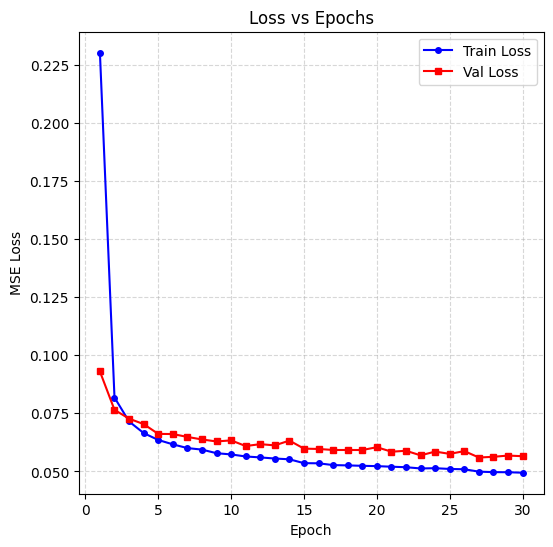

In [ ]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(6, 6))
plt.plot(epochs_range, history["train_loss"], "b-o", markersize=4, label="Train Loss")
plt.plot(epochs_range, history["val_loss"], "r-s", markersize=4, label="Val Loss")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#Prediction vs Actual

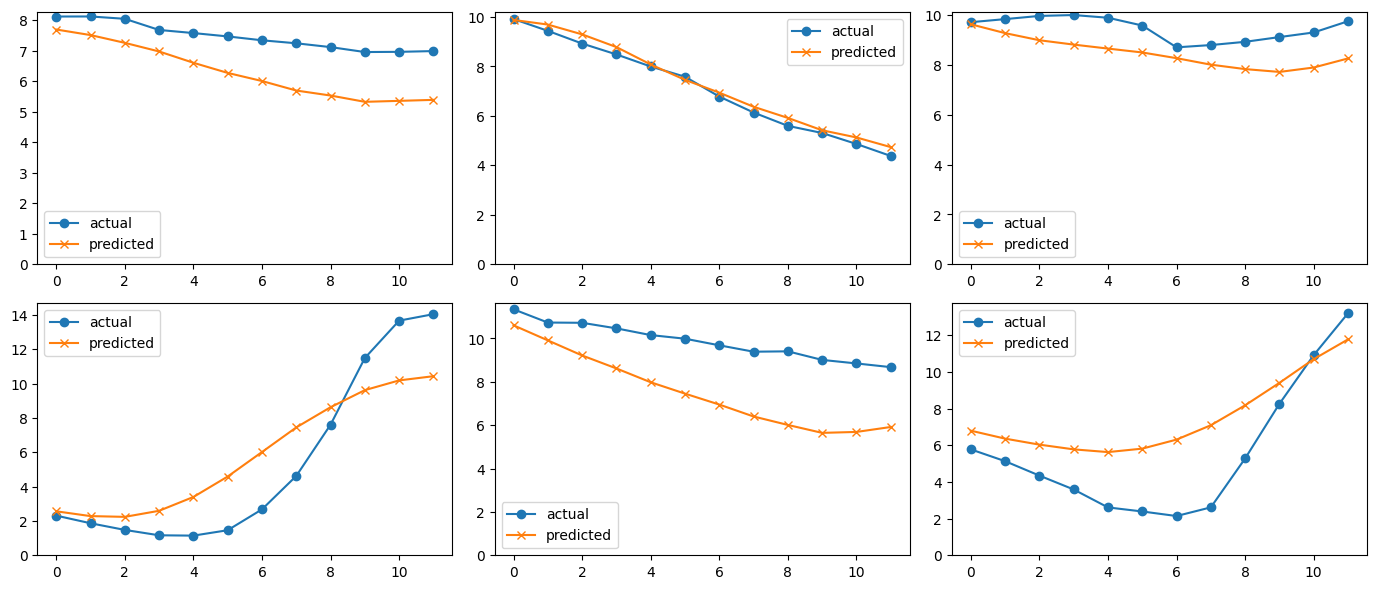

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, idx in zip(axes.flat, [0, 20, 50, 80, 120, 150]):
    pred_denorm = preds[idx].cpu().numpy() * target_std + target_mean
    true_denorm = yb[idx].cpu().numpy() * target_std + target_mean
    ax.plot(true_denorm, label="actual", marker="o")
    ax.plot(pred_denorm, label="predicted", marker="x")
    ax.set_ylim(bottom=0)
    ax.legend()
plt.tight_layout()
plt.show()